## Random Forest

Random Forest is an ensemble of Decision Trees. With a few exceptions, a `RandomForestClassifier` has all the hyperparameters of a `DecisionTreeClassifier` (to control how trees are grown), plus all the hyperparameters of a `BaggingClassifier` to control the ensemble itself.

The Random Forest algorithm introduces extra randomness when growing trees; instead of searching for the very best feature when splitting a node, it searches for the best feature among a random subset of features. This results in a greater tree diversity, which (once again) trades a higher bias for a lower variance, generally yielding an overall better model. The following `BaggingClassifier` is roughly equivalent to the previous `RandomForestClassifier`. Run the cell below to visualize a single estimator from a random forest model, using the Iris dataset to classify the data into the appropriate species.

In [2]:
import os
os.environ["PATH"] += os.pathsep + r"C:\Program Files\Graphviz\bin"

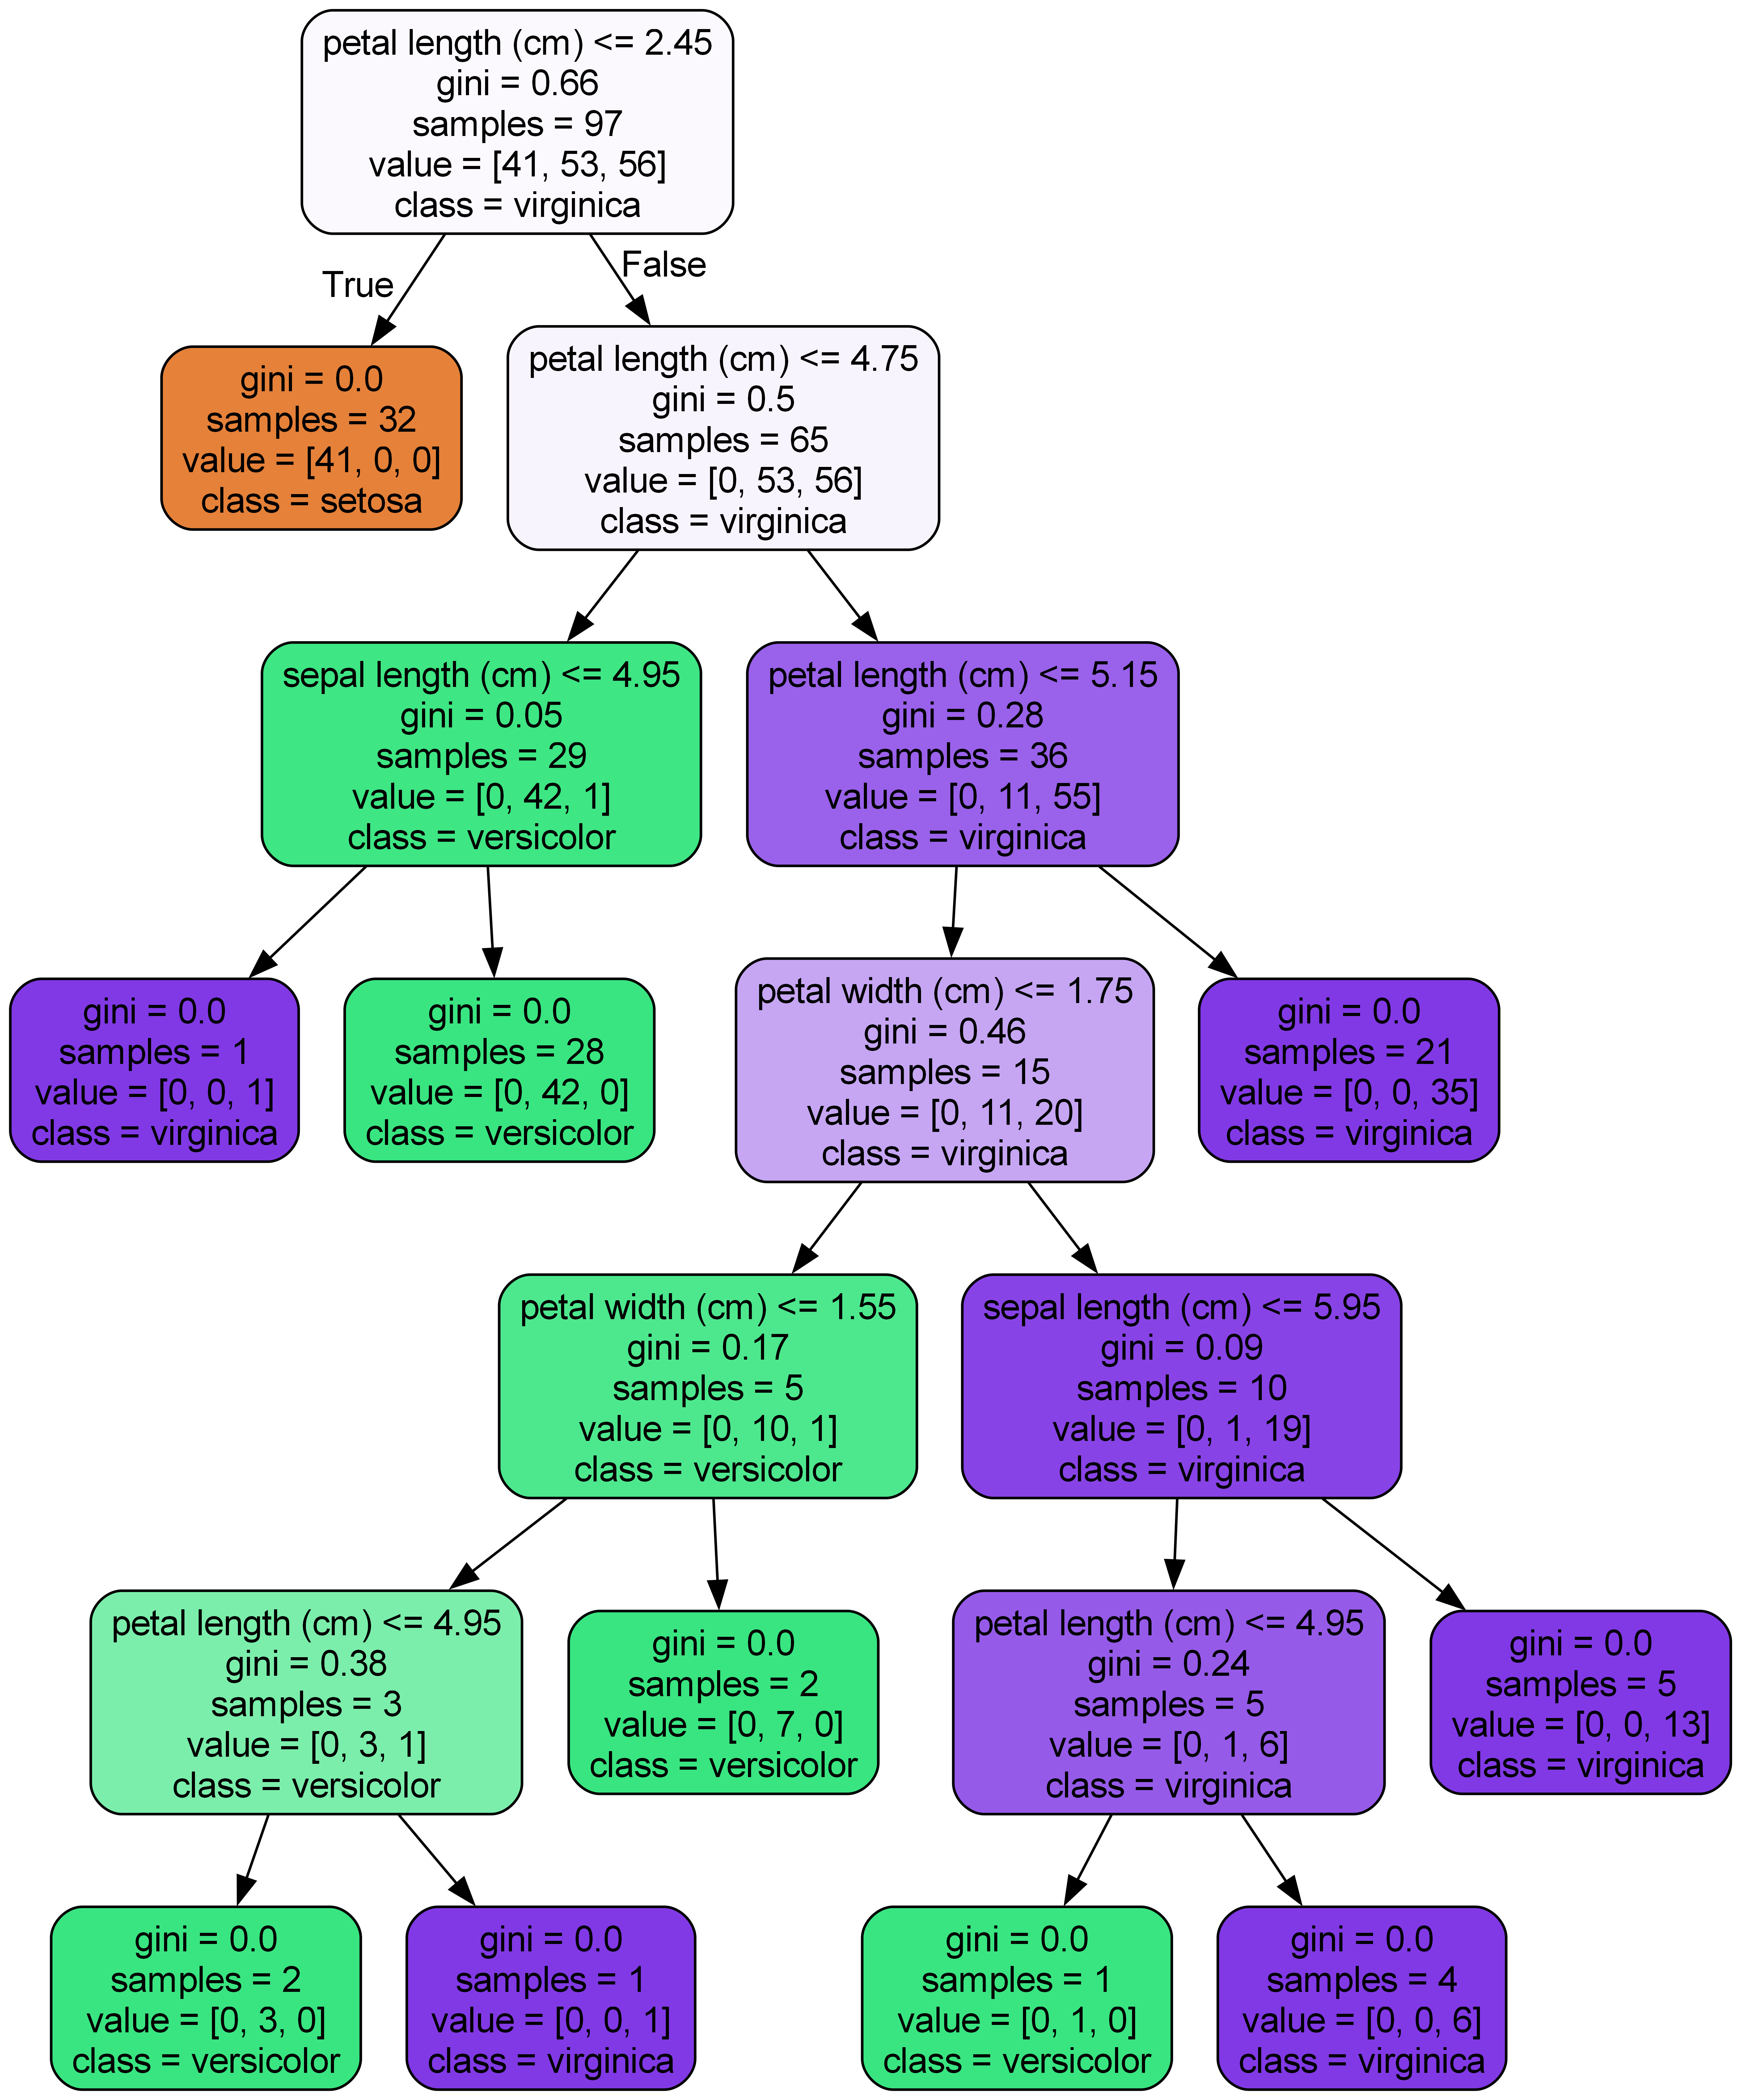

In [3]:
from sklearn.datasets import load_iris
iris = load_iris()

# Model (can also use single decision tree)
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=10)

# Train
model.fit(iris.data, iris.target)
# Extract single tree
estimator = model.estimators_[5]

from sklearn.tree import export_graphviz
# Export as dot file
export_graphviz(estimator, out_file='tree.dot', 
               feature_names = iris.feature_names,
              class_names = iris.target_names,
                rounded = True, proportion = False, 
               precision = 2, filled = True)

# Convert to png using system command (requires Graphviz)
#from subprocess import call
#call(['dot', '-Tpng', 'tree.dot', '-o', 'tree.png', '-Gdpi=600'])


#call([
 #   r"C:\Users\VBACOMishrR\Graphviz-14.1.5-win64\bin\dot.exe",
  #  '-Tpng',
   # 'tree.dot',
    #'-o',
    #'tree.png',
    #'-Gdpi=600'
#])


# Display in jupyter notebook
from IPython.display import Image
Image(filename = 'tree.png')

Notice how each split seperates the data into buckets of similar observations. This is a single tree and a relatively simple classification dataset, but the same method is used in a more complex dataset with greater depth to the trees.

## Coronavirus
Coronavirus disease (COVID-19) is an infectious disease caused by a new virus.
The disease causes respiratory illness (like the flu) with symptoms such as a cough, fever, and in more severe cases, difficulty breathing. You can protect yourself by washing your hands frequently, avoiding touching your face, and avoiding close contact (1 meter or 3 feet) with people who are unwell. An outbreak of COVID-19 started in December 2019 and at the time of the creation of this project was continuing to spread throughout the world. Many governments recommended only essential outings to public places and closed most business that do not serve food or sell essential items. An excellent [spatial dashboard](https://www.arcgis.com/apps/opsdashboard/index.html#/bda7594740fd40299423467b48e9ecf6) built by Johns Hopkins shows the daily confirmed cases by country. 

This case study was designed to drive home the important role that data science plays in real-world situations like this pandemic. This case study uses the Random Forest Classifier and a dataset from the South Korean cases of COVID-19 provided on [Kaggle](https://www.kaggle.com/kimjihoo/coronavirusdataset) to encourage research on this important topic. The goal of the case study is to build a Random Forest Classifier to predict the 'state' of the patient.

First, please load the needed packages and modules into Python. Next, load the data into a pandas dataframe for ease of use.

In [4]:
import os
import pandas as pd
from datetime import datetime,timedelta
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline
import plotly.graph_objects as go
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import ExtraTreesRegressor

In [5]:
url =r"C:\Users\VBACOMishrR\OneDrive - Department of Veterans Affairs\Documents\DataScienceGuidedCapstone\SouthKoreacoronavirusdataset-20200630T044816Z-001\SouthKoreacoronavirusdataset\patientinfo.csv"
df = pd.read_csv(url)
df.head()

,patient_id,global_num,sex,birth_year,age,country,province,city,disease,infection_case,infection_order,infected_by,contact_number,symptom_onset_date,confirmed_date,released_date,deceased_date,state
0,1000000001,2.0,male,1964.0,50s,Korea,Seoul,Gangseo-gu,NaN,overseas inflow,1.0,NaN,75.0,2020-01-22,2020-01-23,2020-02-05,NaN,released
1,1000000002,5.0,male,1987.0,30s,Korea,Seoul,Jungnang-gu,NaN,overseas inflow,1.0,NaN,31.0,NaN,2020-01-30,2020-03-02,NaN,released
2,1000000003,6.0,male,1964.0,50s,Korea,Seoul,Jongno-gu,NaN,contact with patient,2.0,2.002000e+09,17.0,NaN,2020-01-30,2020-02-19,NaN,released
3,1000000004,7.0,male,1991.0,20s,Korea,Seoul,Mapo-gu,NaN,overseas inflow,1.0,NaN,9.0,2020-01-26,2020-01-30,2020-02-15,NaN,released
4,1000000005,9.0,female,1992.0,20s,Korea,Seoul,Seongbuk-gu,NaN,contact with patient,2.0,1.000000e+09,2.0,NaN,2020-01-31,2020-02-24,NaN,released


In [6]:
df.shape

(2218, 18)

In [7]:
#Counts of null values 
na_df=pd.DataFrame(df.isnull().sum().sort_values(ascending=False)).reset_index()
na_df.columns = ['VarName', 'NullCount']
na_df[(na_df['NullCount']>0)]

,VarName,NullCount
0,disease,2199
1,deceased_date,2186
2,infection_order,2176
3,symptom_onset_date,2025
4,released_date,1995
5,contact_number,1807
6,infected_by,1749
7,infection_case,1055
8,global_num,904
9,birth_year,454


In [8]:
#counts of response variable values
df.state.value_counts()

state
isolated    1791
released     307
deceased      32
Name: count, dtype: int64

 **<font color='teal'> Create a new column named 'n_age' which is the calculated age based on the birth year column.</font>**

In [9]:
#create a new column called 'n_age' for age group
def n_age(age):
    if age == '80-89':
        return 85
    elif age == '70-79':
        return 75
    elif age == '60-69':
        return 65
    elif age == '50-59':
        return 55
    elif age == '40-49':
        return 45
    elif age == '30-39':
        return 35
    elif age == '20-29':
        return 25
    elif age == '10-19':
        return 15
    elif age == '0-9':
        return 5
    else:
        return np.nan

### Handle Missing Values

 **<font color='teal'> Print the number of missing values by column.</font>**

In [10]:
#print number of missing values in n_age column
df['n_age'] = df.age.apply(n_age)
print(df['n_age'].isnull().sum())


2218


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2218 entries, 0 to 2217
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   patient_id          2218 non-null   int64  
 1   global_num          1314 non-null   float64
 2   sex                 2073 non-null   object 
 3   birth_year          1764 non-null   float64
 4   age                 1957 non-null   object 
 5   country             2218 non-null   object 
 6   province            2218 non-null   object 
 7   city                2153 non-null   object 
 8   disease             19 non-null     object 
 9   infection_case      1163 non-null   object 
 10  infection_order     42 non-null     float64
 11  infected_by         469 non-null    float64
 12  contact_number      411 non-null    float64
 13  symptom_onset_date  193 non-null    object 
 14  confirmed_date      2077 non-null   object 
 15  released_date       223 non-null    object 
 16  deceas

 **<font color='teal'> Fill the 'disease' missing values with 0 and remap the True values to 1.</font>**

In [12]:
#fill disease missing values with 0 and remap the True values to 1
df['disease'] = df['disease'].fillna(0)
df['disease'] = df['disease'].map({True: 1, False: 0})


 **<font color='teal'> Fill null values in the following columns with their mean: 'global_number','birth_year','infection_order','infected_by'and 'contact_number'</font>**

In [ ]:
#fill null values in n_age column with their mean : 'global_number', 'birth_year', 'infection_order','infected_by' and 'contact_number'
imputer = IterativeImputer(estimator=ExtraTreesRegressor(), max_iter=10, random_state=0)
df['n_age'] = imputer.fit_transform(df[['n_age']])
df['n_age'].fillna(0)


0       6.476968e-310
1       6.476968e-310
2       6.476968e-310
3       6.476968e-310
4       6.476968e-310
            ...      
2213    6.476968e-310
2214    6.476968e-310
2215    6.476968e-310
2216    6.476968e-310
2217    6.476968e-310
Name: n_age, Length: 2218, dtype: float64

 **<font color='teal'> Fill the rest of the missing values with any method.</font>**

In [ ]:
#fill missing values in n_age column with any method (mean, median, mode, etc.)
df['n_age'] = df['n_age'].fillna(df['n_age'].mean())


 **<font color='teal'> Check for any remaining null values.</font>**

In [18]:
#check if there are any missing values left
df.isnull().sum()

patient_id               0
global_num             904
sex                    145
birth_year             454
age                    261
country                  0
province                 0
city                    65
disease                  0
infection_case        1055
infection_order       2176
infected_by           1749
contact_number        1807
symptom_onset_date    2025
confirmed_date         141
released_date         1995
deceased_date         2186
state                   88
n_age                    0
dtype: int64

In [19]:
df.head()

,patient_id,global_num,sex,birth_year,age,country,province,city,disease,infection_case,infection_order,infected_by,contact_number,symptom_onset_date,confirmed_date,released_date,deceased_date,state,n_age
0,1000000001,2.0,male,1964.0,50s,Korea,Seoul,Gangseo-gu,0,overseas inflow,1.0,NaN,75.0,2020-01-22,2020-01-23,2020-02-05,NaN,released,6.476968e-310
1,1000000002,5.0,male,1987.0,30s,Korea,Seoul,Jungnang-gu,0,overseas inflow,1.0,NaN,31.0,NaN,2020-01-30,2020-03-02,NaN,released,6.476968e-310
2,1000000003,6.0,male,1964.0,50s,Korea,Seoul,Jongno-gu,0,contact with patient,2.0,2.002000e+09,17.0,NaN,2020-01-30,2020-02-19,NaN,released,6.476968e-310
3,1000000004,7.0,male,1991.0,20s,Korea,Seoul,Mapo-gu,0,overseas inflow,1.0,NaN,9.0,2020-01-26,2020-01-30,2020-02-15,NaN,released,6.476968e-310
4,1000000005,9.0,female,1992.0,20s,Korea,Seoul,Seongbuk-gu,0,contact with patient,2.0,1.000000e+09,2.0,NaN,2020-01-31,2020-02-24,NaN,released,6.476968e-310


Remove date columns from the data.


In [20]:
df = df.drop(['symptom_onset_date','confirmed_date','released_date','deceased_date'],axis =1)

Review the count of unique values by column.

In [21]:
print(df.nunique())

patient_id         2218
global_num         1303
sex                   2
birth_year           96
age                  11
country               4
province             17
city                134
disease               2
infection_case       16
infection_order       6
infected_by         206
contact_number       72
state                 3
n_age                 1
dtype: int64


Review the percent of unique values by column.

In [22]:
print(df.nunique()/df.shape[0])

patient_id         1.000000
global_num         0.587466
sex                0.000902
birth_year         0.043282
age                0.004959
country            0.001803
province           0.007665
city               0.060415
disease            0.000902
infection_case     0.007214
infection_order    0.002705
infected_by        0.092876
contact_number     0.032462
state              0.001353
n_age              0.000451
dtype: float64


Review the range of values per column.

In [23]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
patient_id,2218.0,4.014678e+09,2.192419e+09,1.000000e+09,1.700000e+09,6.001000e+09,6.004000e+09,7.000000e+09
global_num,1314.0,4.664817e+03,2.874044e+03,1.000000e+00,1.908500e+03,5.210500e+03,7.481500e+03,8.717000e+03
birth_year,1764.0,1.974989e+03,1.941264e+01,1.916000e+03,1.962000e+03,1.974500e+03,1.993000e+03,2.020000e+03
disease,2218.0,8.566276e-03,9.217769e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
infection_order,42.0,2.285714e+00,1.254955e+00,1.000000e+00,1.250000e+00,2.000000e+00,3.000000e+00,6.000000e+00
infected_by,469.0,2.600789e+09,1.570638e+09,1.000000e+09,1.200000e+09,2.000000e+09,4.100000e+09,6.113000e+09
contact_number,411.0,2.412895e+01,9.108779e+01,0.000000e+00,2.000000e+00,5.000000e+00,1.600000e+01,1.160000e+03
n_age,2218.0,6.476968e-310,0.000000e+00,6.476968e-310,6.476968e-310,6.476968e-310,6.476968e-310,6.476968e-310


### Check for duplicated rows

In [24]:
duplicateRowsDF = df[df.duplicated()]
duplicateRowsDF

,patient_id,global_num,sex,birth_year,age,country,province,city,disease,infection_case,infection_order,infected_by,contact_number,state,n_age


Print the categorical columns and their associated levels.

In [25]:
dfo = df.select_dtypes(include=['object'], exclude=['datetime'])
dfo.shape
#get levels for all variables
vn = pd.DataFrame(dfo.nunique()).reset_index()
vn.columns = ['VarName', 'LevelsCount']
vn.sort_values(by='LevelsCount', ascending =False)
vn

,VarName,LevelsCount
0,sex,2
1,age,11
2,country,4
3,province,17
4,city,134
5,infection_case,16
6,state,3


**<font color='teal'> Plot the correlation heat map for the features.</font>**

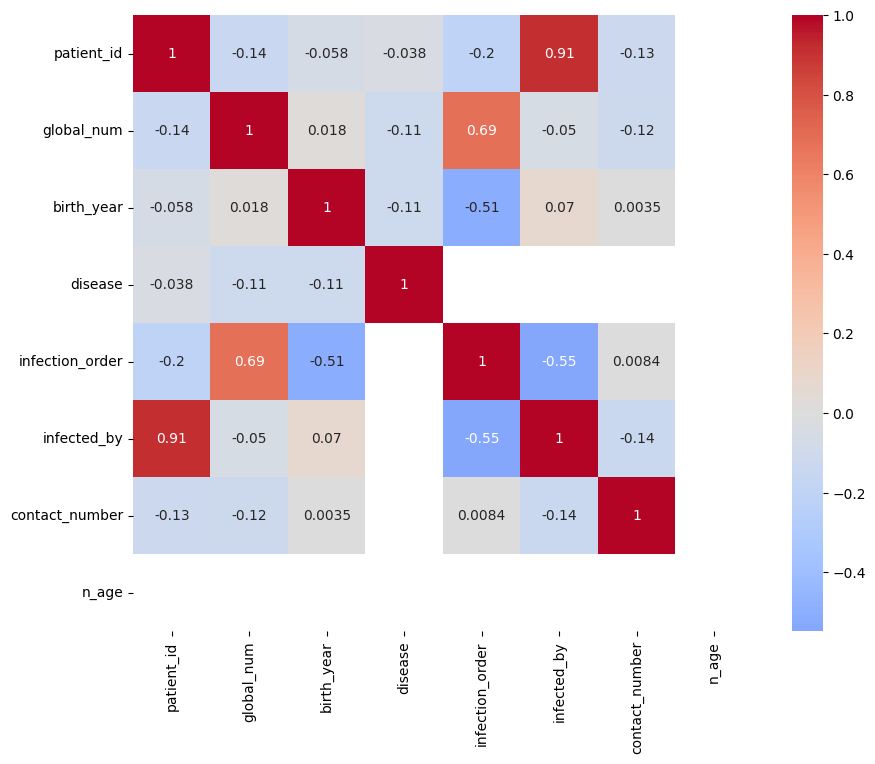

In [26]:
#plot correlation heatmap for the features

import matplotlib.pyplot as plt
df.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm',
            center=0)

plt.show()



**<font color='teal'> Plot the boxplots to check for outliers. </font>**

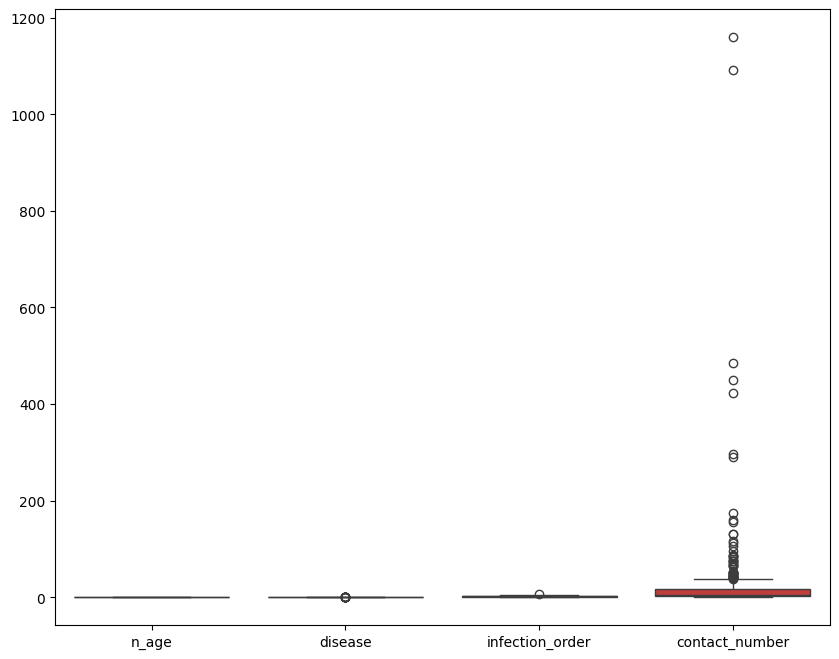

In [27]:
#plot boxplots to check for outliers
plt.figure(figsize=(10, 8))
sns.boxplot(data=df[['n_age','disease','infection_order','contact_number']])
plt.show()


**<font color='teal'> Create dummy features for object type features. </font>**

In [28]:
#create dummy features for object type features
df = pd.get_dummies(df, columns=['disease'], drop_first=True)


### Split the data into test and train subsamples

In [29]:
from sklearn.model_selection import train_test_split
# dont forget to define your X and y
X=df.drop('state', axis=1)
y=df['state']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=1)

### Scale data to prep for model creation

In [42]:
#scale data
#from sklearn import preprocessing
#import numpy as np
# build scaler based on training data and apply it to test data to then also scale the test data
#scaler = preprocessing.StandardScaler().fit(X_train)
#X_train_scaled=scaler.transform(X_train)
#X_test_scaled=scaler.transform(X_test)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
import pandas as pd
import numpy as np

# Example: automatically detect column types
numeric_features = X_train.select_dtypes(include=[np.number]).columns
categorical_features = X_train.select_dtypes(include=['object', 'category']).columns

# Numeric preprocessing
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

# Categorical preprocessing
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine preprocessors
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# Fit on training data only
X_train_scaled = preprocessor.fit_transform(X_train)

# Apply same transformations to test data
X_test_scaled = preprocessor.transform(X_test)

In [31]:
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import f1_score
from sklearn.metrics import auc
from sklearn.linear_model import LogisticRegression
from matplotlib import pyplot
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import f1_score
from sklearn.metrics import auc
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report,confusion_matrix,roc_curve,roc_auc_score
from sklearn.metrics import accuracy_score,log_loss
from matplotlib import pyplot

### Fit Random Forest Classifier
The fit model shows an overall accuracy of 80% which is great and indicates our model was effectively able to identify the status of a patients in the South Korea dataset.

In [58]:
#claude suggested

import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

# ── Pre-pipeline cleanup ──────────────────────────────────────────────────────
for df in [X_train, X_test]:
    # Replace all fake NaN strings
    df.replace({'nan': np.nan, 'None': np.nan, 'null': np.nan,
                 'NaN': np.nan, '': np.nan}, inplace=True)
    # Replace infinity
    df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Drop NaN in target
mask_train = pd.Series(y_train).notna()
mask_test  = pd.Series(y_test).notna()
X_train, y_train = X_train[mask_train.values], y_train[mask_train.values]
X_test,  y_test  = X_test[mask_test.values],   y_test[mask_test.values]

# ── Column type detection ─────────────────────────────────────────────────────
num_cols = X_train.select_dtypes(include=['number']).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

# ── Sub-pipelines ─────────────────────────────────────────────────────────────
numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# ── Combined preprocessor ─────────────────────────────────────────────────────
preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_pipeline, num_cols),
    ('cat', categorical_pipeline, cat_cols)
], remainder='drop')           # ← drops any unclassified columns safely

# ── Full pipeline ─────────────────────────────────────────────────────────────
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', RandomForestClassifier(n_estimators=300,
                                    random_state=1,
                                    n_jobs=-1))
])

pipeline.fit(X_train, y_train)

# ── Verify no NaNs slipped through ───────────────────────────────────────────
X_train_transformed = preprocessor.fit_transform(X_train)
print("NaNs after transform:", np.isnan(X_train_transformed).sum())  # must be 0

y_pred      = pipeline.predict(X_test)
y_pred_prob = pipeline.predict_proba(X_test)

print('Accuracy : %.3f' % accuracy_score(y_test, y_pred))
print('F1-Score : %.3f' % f1_score(y_test, y_pred, average='weighted'))
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred))

NaNs after transform: 0
Accuracy : 0.850
F1-Score : 0.818
Confusion Matrix:
 [[  6   1   0]
 [  1 342   8]
 [  0  54  15]]


In [59]:
#claude suggested find where NaN values are in the dataset

import pandas as pd
import numpy as np

# Check raw data BEFORE any pipeline
print("=== X_train ===")
print(X_train.isnull().sum()[X_train.isnull().sum() > 0])  # only cols with NaNs

print("\n=== X_test ===")
print(X_test.isnull().sum()[X_test.isnull().sum() > 0])

print("\n=== y_train ===")
print(pd.Series(y_train).isnull().sum())

print("\n=== y_test ===")
print(pd.Series(y_test).isnull().sum())

# Check dtypes — misclassified columns are a common hidden cause
print("\n=== Column dtypes ===")
print(X_train.dtypes)

=== X_train ===
global_num          724
sex                 117
birth_year          365
age                 145
city                 51
infection_case      831
infection_order    1670
infected_by        1377
contact_number     1375
dtype: int64

=== X_test ===
global_num         173
sex                 28
birth_year          89
age                 29
city                14
infection_case     223
infection_order    418
infected_by        351
contact_number     346
dtype: int64

=== y_train ===
0

=== y_test ===
0

=== Column dtypes ===
patient_id           int64
global_num         float64
sex                 object
birth_year         float64
age                 object
country             object
province            object
city                object
infection_case      object
infection_order    float64
infected_by        float64
contact_number     float64
n_age              float64
disease_1             bool
dtype: object


In [60]:
#claude suggested

import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

# ── Step 1: Identify column types ────────────────────────────────────────────
# If X_train is a DataFrame
num_cols = X_train.select_dtypes(include=['number']).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

print("Numerical columns:", num_cols)
print("Categorical columns:", cat_cols)

# ── Step 2: Build separate pipelines per column type ─────────────────────────
numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),   # fill NaN with column mean
    ('scaler',  StandardScaler())                  # scale to unit variance
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),  # fill NaN with mode
    ('encoder', OneHotEncoder(handle_unknown='ignore',     # encode strings → numbers
                              sparse_output=False))        # dense output
])

# ── Step 3: Combine with ColumnTransformer ────────────────────────────────────
preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_pipeline, num_cols),
    ('cat', categorical_pipeline, cat_cols)
])

# ── Step 4: Full pipeline with classifier ─────────────────────────────────────
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', RandomForestClassifier(n_estimators=300,
                                   random_state=1,
                                   n_jobs=-1))
])

# ── Step 5: Fit and evaluate ──────────────────────────────────────────────────
pipeline.fit(X_train, y_train)  # use RAW X_train/X_test, not pre-scaled

y_pred      = pipeline.predict(X_test)
y_pred_prob = pipeline.predict_proba(X_test)
lr_probs    = y_pred_prob[:, 1]

ac = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')
cm = confusion_matrix(y_test, y_pred)

print('Random Forest: Accuracy=%.3f' % (ac))
print('Random Forest: f1-score=%.3f' % (f1))
print('Confusion Matrix:\n', cm)

# If X_train is a NumPy array (not a DataFrame), convert first
X_train = pd.DataFrame(X_train)
X_test  = pd.DataFrame(X_test)

# If a numeric column is stored as string, fix it before the pipeline
X_train['age'] = pd.to_numeric(X_train['age'], errors='coerce')  # bad strings → NaN
X_test['age']  = pd.to_numeric(X_test['age'],  errors='coerce')

# Use median instead of mean if numerical columns have outliers
numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

Numerical columns: ['patient_id', 'global_num', 'birth_year', 'infection_order', 'infected_by', 'contact_number', 'n_age']
Categorical columns: ['sex', 'age', 'country', 'province', 'city', 'infection_case']
Random Forest: Accuracy=0.850
Random Forest: f1-score=0.821
Confusion Matrix:
 [[  6   1   0]
 [  1 341   9]
 [  0  53  16]]


Numerical columns   : ['patient_id', 'global_num', 'birth_year', 'age', 'infection_order', 'infected_by', 'contact_number', 'n_age']
Categorical columns : ['sex', 'country', 'province', 'city', 'infection_case']


c:\Users\VBACOMishrR\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['age']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


Feature names count : 172
Importances shape   : (171,)


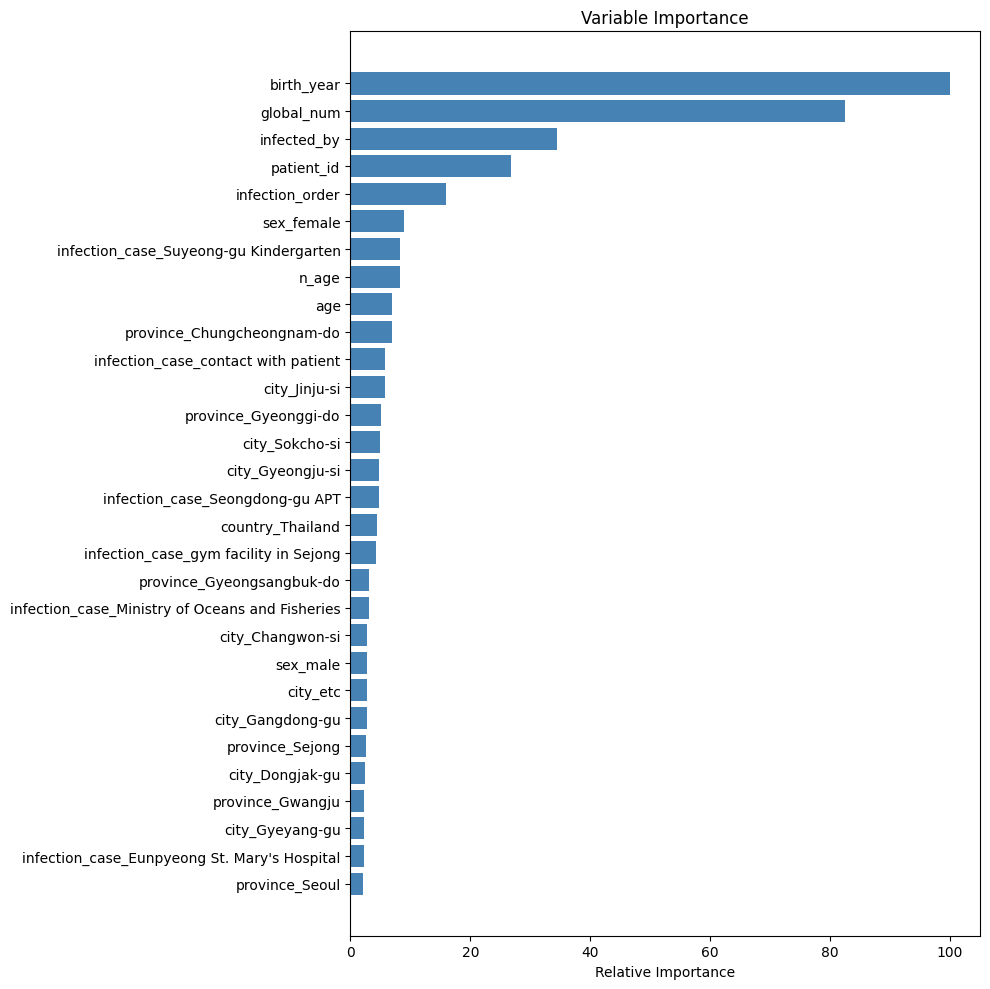

In [81]:
#claude suggested to rebuild pipeline correctly with mixed data
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier

# ── Pre-pipeline cleanup ──────────────────────────────────────────────────────
for df in [X_train, X_test]:
    df.replace({'nan': np.nan, 'None': np.nan, 'null': np.nan,
                 'NaN': np.nan, '': np.nan}, inplace=True)
    df.replace([np.inf, -np.inf], np.nan, inplace=True)

# ── Detect column types ───────────────────────────────────────────────────────
num_cols = X_train.select_dtypes(include=['number']).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Numerical columns   : {num_cols}")
print(f"Categorical columns : {cat_cols}")

# ── Sub-pipelines ─────────────────────────────────────────────────────────────
numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# ── ColumnTransformer ─────────────────────────────────────────────────────────
preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_pipeline, num_cols),
    ('cat', categorical_pipeline, cat_cols)
], remainder='drop')

# ── Full pipeline ─────────────────────────────────────────────────────────────
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', RandomForestClassifier(n_estimators=300,
                                    random_state=1,
                                    n_jobs=-1))
])

pipeline.fit(X_train, y_train)

# ── Feature names ─────────────────────────────────────────────────────────────
cat_feature_names = pipeline['preprocessor'] \
                        .named_transformers_['cat']['encoder'] \
                        .get_feature_names_out(cat_cols).tolist()

all_feature_names = np.array(num_cols + cat_feature_names)
clf               = pipeline['clf']

print(f"Feature names count : {len(all_feature_names)}")
print(f"Importances shape   : {clf.feature_importances_.shape}")  # must match

# ── Plot ──────────────────────────────────────────────────────────────────────
feature_importance = clf.feature_importances_
feature_importance = 100.0 * (feature_importance / feature_importance.max())
sorted_idx         = np.argsort(feature_importance)[-30:]

pos = np.arange(len(sorted_idx)) + 0.5
plt.figure(figsize=(10, 10))
plt.barh(pos, feature_importance[sorted_idx], align='center', color='steelblue')
plt.yticks(pos, all_feature_names[sorted_idx])
plt.xlabel('Relative Importance')
plt.title('Variable Importance')
plt.tight_layout()
plt.show()

### Create Confusion Matrix Plots
Confusion matrices are great ways to review your model performance for a multi-class classification problem. Being able to identify which class the misclassified observations end up in is a great way to determine if you need to build additional features to improve your overall model. In the example below we plot a regular counts confusion matrix as well as a weighted percent confusion matrix. The percent confusion matrix is particulary helpful when you have unbalanced class sizes.

In [82]:
class_names=['isolated','released','missing','deceased'] # name  of classes

Confusion matrix, without normalization
[[  6   1   0]
 [  1 341   9]
 [  0  53  16]]
Normalized confusion matrix
[[0.86 0.14 0.  ]
 [0.   0.97 0.03]
 [0.   0.77 0.23]]


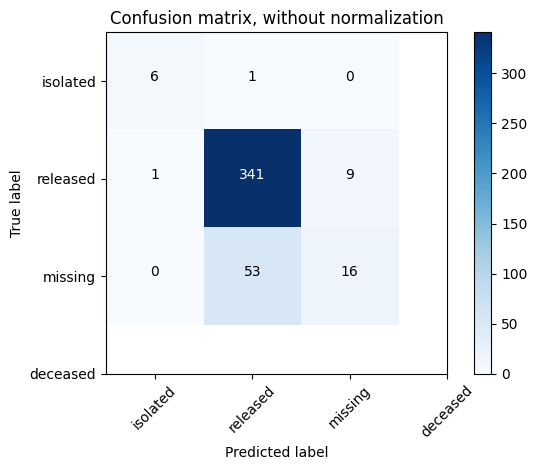

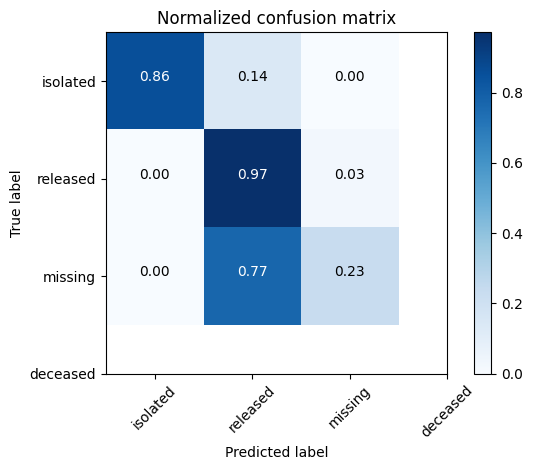

In [83]:
import itertools
import numpy as np
import matplotlib.pyplot as plt

from sklearn import svm, datasets
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()


# Compute confusion matrix
cnf_matrix = confusion_matrix(y_test, y_pred)
np.set_printoptions(precision=2)

# Plot non-normalized confusion matrix
plt.figure()
plot_confusion_matrix(cnf_matrix, classes=class_names,
                      title='Confusion matrix, without normalization')
#plt.savefig('figures/RF_cm_multi_class.png')

# Plot normalized confusion matrix
plt.figure()
plot_confusion_matrix(cnf_matrix, classes=class_names, normalize=True,
                      title='Normalized confusion matrix')
#plt.savefig('figures/RF_cm_proportion_multi_class.png', bbox_inches="tight")
plt.show()

### Plot feature importances
The random forest algorithm can be used as a regression or classification model. In either case it tends to be a bit of a black box, where understanding what's happening under the hood can be difficult. Plotting the feature importances is one way that you can gain a perspective on which features are driving the model predictions.

In [84]:
# Print all step names in your pipeline
print(pipeline.named_steps.keys())

# Also print full pipeline structure
print(pipeline)

dict_keys(['preprocessor', 'clf'])
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['patient_id', 'global_num',
                                                   'birth_year', 'age',
                                                   'infection_order',
                                                   'infected_by',
                                                   'contact_number', 'n_age']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                            

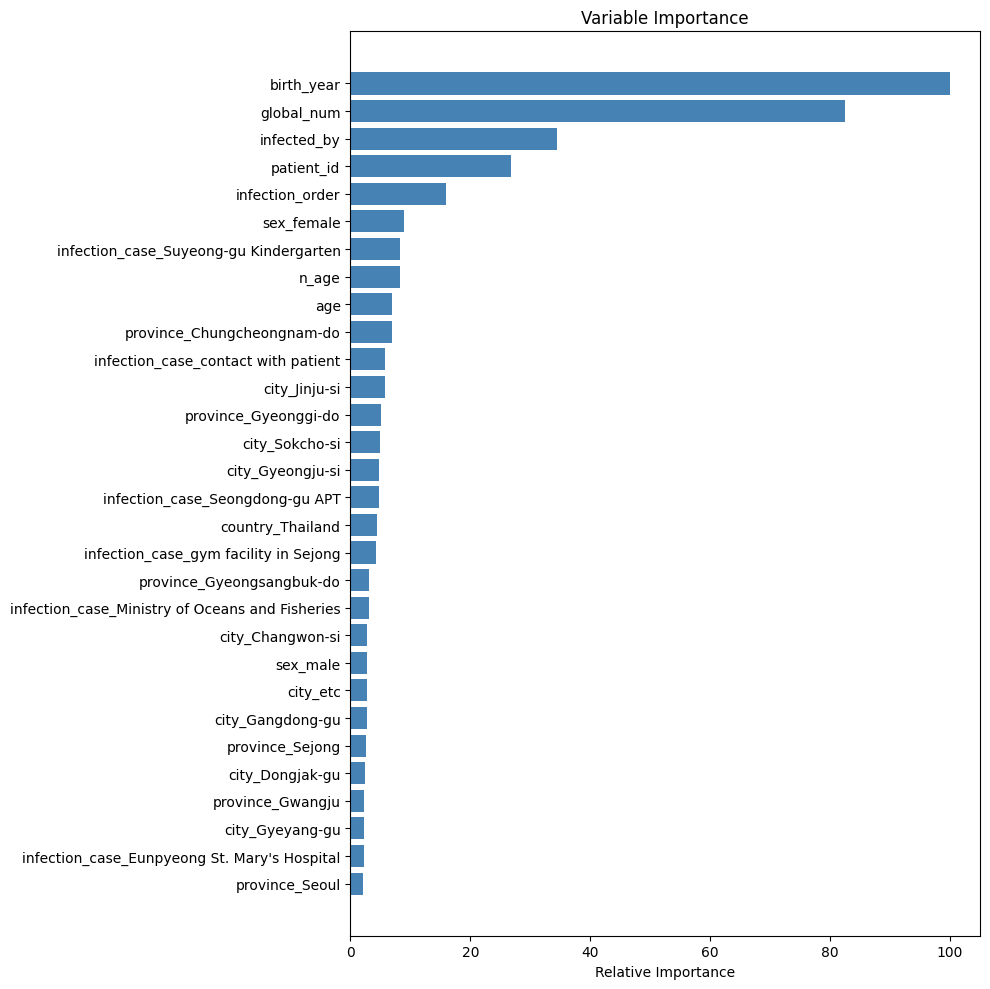

In [85]:
#claude suggested
# ── Extract fitted clf from pipeline ─────────────────────────────────────────
clf = pipeline['clf']  # ✅ this is the actually fitted model

# ── Extract correct feature names ─────────────────────────────────────────────
cat_feature_names = pipeline['preprocessor'] \
                        .named_transformers_['cat']['encoder'] \
                        .get_feature_names_out(cat_cols).tolist()

all_feature_names = np.array(num_cols + cat_feature_names)

# ── Feature importance ────────────────────────────────────────────────────────
feature_importance = clf.feature_importances_
feature_importance = 100.0 * (feature_importance / feature_importance.max())
sorted_idx         = np.argsort(feature_importance)[-30:]  # top 30

# ── Plot ──────────────────────────────────────────────────────────────────────
pos = np.arange(len(sorted_idx)) + 0.5

plt.figure(figsize=(10, 10))
plt.barh(pos, feature_importance[sorted_idx], align='center', color='steelblue')
plt.yticks(pos, all_feature_names[sorted_idx])  # ✅ expanded feature names
plt.xlabel('Relative Importance')
plt.title('Variable Importance')
plt.tight_layout()
plt.show()

The popularity of random forest is primarily due to how well it performs in a multitude of data situations. It tends to handle highly correlated features well, where as a linear regression model would not. In this case study we demonstrate the performance ability even with only a few features and almost all of them being highly correlated with each other.
Random Forest is also used as an efficient way to investigate the importance of a set of features with a large data set. Consider random forest to be one of your first choices when building a decision tree, especially for multiclass classifications.